# SKKU 2024 Challenge #3: Heisenberg Spin Glass

In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import itertools
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [2]:
## utils.py
np.set_printoptions(linewidth=np.inf, precision=3)
backend = Aer.get_backend("aer_simulator")
backend2 = Aer.get_backend("statevector_simulator")

def MeasurementResultHandler(result:dict, num_qubits:int, num_shots:int):
	new_result = {}
	for i in range(2**num_qubits):
		temp = format(i,"#b")[2:]
		key = "".join(["0" for _ in range(num_qubits - len(temp))]) + temp
		new_result[key] = np.array(result[format(i,"#x")])/num_shots if result.get(format(i,"#x")) else np.array(0)
	return new_result

## Part 1

### a), b)

In [3]:
class H_sg():
    def __init__(self, coefficients1, coefficients2=None, num_qubits=4):
        self.num_qubits = num_qubits
        self.coefficients1 = coefficients1
        self.coefficients2 = coefficients2
        self.Pauli_X = np.array([
            [0,1],
            [1,0]
        ], dtype=np.complex64)
        self.Pauli_Y = np.array([
            [0,-1j],
            [1j,0]
        ], dtype=np.complex64)
        self.Pauli_Z = np.array([
            [1,0],
            [0,-1]
        ], dtype=np.complex64)
        self.I = np.eye(2, dtype=np.complex64)
        self.__reset__()
        self._eigenSpectrum()
    
    def _Kron(self, array):
        """
        Calculate the Kronecker product of a list of array.

        Args:
            tensors : list of np.array.
            [A_0, A_1, A_2, ..., A_N]
        Returns:
            prod: the Kronecker product of the input array.
            A_N ⊗ A_{N-1} ⊗ ... ⊗ A_1 ⊗ A_0
        """
        prod = np.array(1)
        if len(array) == 0:
            return prod
        else:
            for element in array:
                prod = np.kron(element, prod) 
            return prod
    
    def __reset__(self):
        qubit_idx = [idx for idx in range(self.num_qubits)]
        combinations = itertools.combinations(qubit_idx, 2)
        
        H_z = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex64)
        if self.coefficients2 is not None:
            for i in range(self.num_qubits):
                temp = [self.I for _ in range(self.num_qubits)]
                temp[i] = self.Pauli_Z
                #print(self.coefficients2[i], i, temp)
                H_z += self.coefficients2[i]*self._Kron(temp)
        
        H_heisenberg = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex64)
        for coefficient, pair_idx in zip(self.coefficients1, combinations):
            #print(coefficient, pair_idx)
            H_heisenberg += coefficient * self._H_ij(pair_idx)
            
        
        self.H_sg = H_heisenberg + H_z
        
    def _H_ij(self, qubit_idx):
        idx_1, idx_2 = list(qubit_idx)
        temp = [self.I for _ in range(self.num_qubits)]
        
        X = temp.copy(); Y = temp.copy(); Z = temp.copy()
        
        X[idx_1] = self.Pauli_X; X[idx_2] = self.Pauli_X
        Y[idx_1] = self.Pauli_Y; Y[idx_2] = self.Pauli_Y
        Z[idx_1] = self.Pauli_Z; Z[idx_2] = self.Pauli_Z
        
        return self._Kron(X) + self._Kron(Y) + self._Kron(Z)
    
    def _eigenSpectrum(self):
        self.e_val, self.e_vec = np.linalg.eigh(self.H_sg)
        return self.e_val
    
    def plot_energy_level(self, title:str=None):
        self._eigenSpectrum()
        
        energy_levels = {}
        for energy in self.e_val:
            is_in_level = False
            for existing_energy in energy_levels.keys():
                if np.isclose(energy, existing_energy):
                    energy_levels[existing_energy] += 1
                    is_in_level = True
                    break
            if not is_in_level:
                energy_levels[energy] = 1
                
        
        fig, ax = plt.subplots(1,1, figsize=(5,4))
        cmap = mpl.colormaps["coolwarm"]
        max_e = np.max(list(energy_levels.keys()))
        min_e = np.min(list(energy_levels.keys()))
        normalize = mpl.colors.Normalize(vmin=min_e, vmax=max_e)

        for idx, (energy, num) in enumerate(energy_levels.items()):
            unit_length = 0.05
            start = 0
            color = cmap(normalize(energy))
            
            label = "$E_{} = {:.2f}$".format(idx, energy)

            for i in range(num):
                if i == 0:  # Add label only for the first line at this energy level
                    ax.axhline(energy, start, start + unit_length, color=color, label=label, linewidth=4.0)
                else:
                    ax.axhline(energy, start, start + unit_length, color=color, linewidth=4.0)
                start += unit_length * 1.5
        handles, labels = ax.get_legend_handles_labels()
        
        if title is not None:
            ax.set_title(title, loc="left", fontsize=30)
        
        ax.set_ylabel(r"$E$", rotation=0, fontsize=16)
        ax.tick_params(axis='y', which='major', labelsize=16)
        ax.legend(handles[::-1], labels[::-1], fontsize=16)
        ax.get_xaxis().set_ticks([])
        fig.tight_layout()
        #ax.grid()
        return fig, ax

In [4]:
symmetry_classes = {}
for coefficient_combination in itertools.product([1, -1], repeat=6):
    eigenspectrum = H_sg(coefficient_combination, [0, 0, 0, 0])
    symmetry_classes[coefficient_combination] = eigenspectrum

classified_groups = {}
unique_eigenspectra = {}
class_count = 0

for combination, spectrum in symmetry_classes.items():
    is_duplicate = False
    for class_id, class_spectrum in unique_eigenspectra.items():
        if np.allclose(class_spectrum, spectrum._eigenSpectrum()):
            is_duplicate = True
            classified_groups[class_id].append(combination)
            break

    if is_duplicate:
        continue
    else:
        class_count += 1
        classified_groups[class_count] = [combination]
        unique_eigenspectra[class_count] = spectrum._eigenSpectrum()
        
#print(classified_groups, unique_eigenspectra)

print("num of unique eigenspectra ", len(unique_eigenspectra))
for key, value in classified_groups.items():
    print("Class {}: {}".format(key, value))

num of unique eigenspectra  11
Class 1: [(1, 1, 1, 1, 1, 1)]
Class 2: [(1, 1, 1, 1, 1, -1), (1, 1, 1, 1, -1, 1), (1, 1, 1, -1, 1, 1), (1, 1, -1, 1, 1, 1), (1, -1, 1, 1, 1, 1), (-1, 1, 1, 1, 1, 1)]
Class 3: [(1, 1, 1, 1, -1, -1), (1, 1, 1, -1, 1, -1), (1, 1, 1, -1, -1, 1), (1, 1, -1, 1, 1, -1), (1, 1, -1, 1, -1, 1), (1, -1, 1, 1, 1, -1), (1, -1, 1, -1, 1, 1), (1, -1, -1, 1, 1, 1), (-1, 1, 1, 1, -1, 1), (-1, 1, 1, -1, 1, 1), (-1, 1, -1, 1, 1, 1), (-1, -1, 1, 1, 1, 1)]
Class 4: [(1, 1, 1, -1, -1, -1), (1, -1, -1, 1, 1, -1), (-1, 1, -1, 1, -1, 1), (-1, -1, 1, -1, 1, 1)]
Class 5: [(1, 1, -1, 1, -1, -1), (1, -1, 1, -1, 1, -1), (-1, 1, 1, -1, -1, 1), (-1, -1, -1, 1, 1, 1)]
Class 6: [(1, 1, -1, -1, 1, 1), (1, -1, 1, 1, -1, 1), (-1, 1, 1, 1, 1, -1)]
Class 7: [(1, 1, -1, -1, 1, -1), (1, 1, -1, -1, -1, 1), (1, -1, 1, 1, -1, -1), (1, -1, 1, -1, -1, 1), (1, -1, -1, 1, -1, 1), (1, -1, -1, -1, 1, 1), (-1, 1, 1, 1, -1, -1), (-1, 1, 1, -1, 1, -1), (-1, 1, -1, 1, 1, -1), (-1, 1, -1, -1, 1, 1), (-1, -1, 

### c)

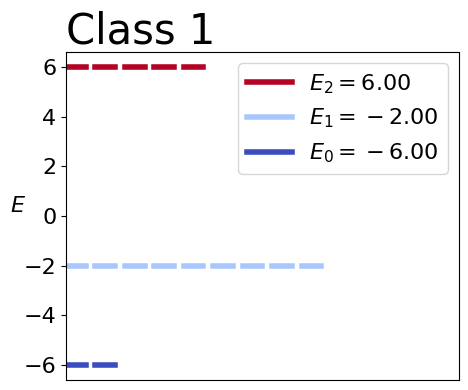

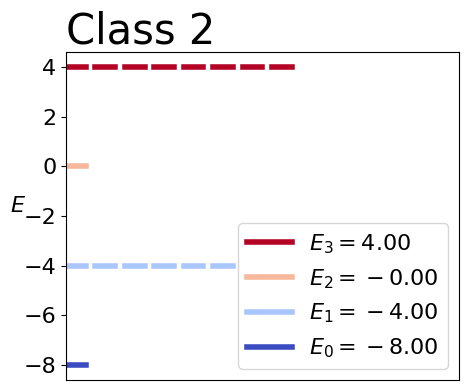

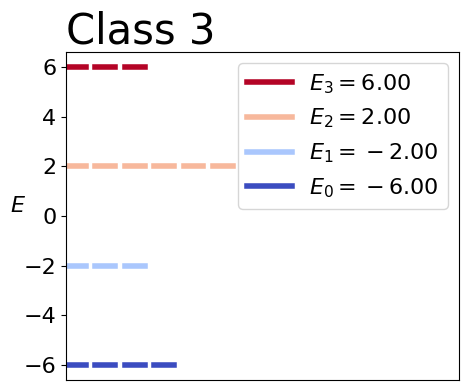

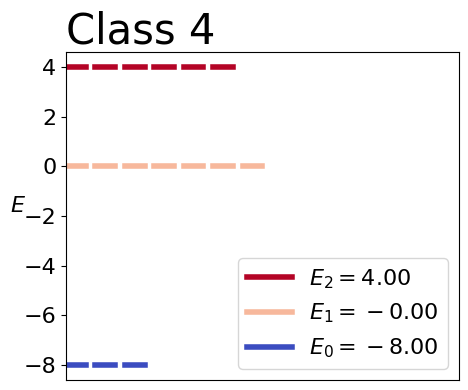

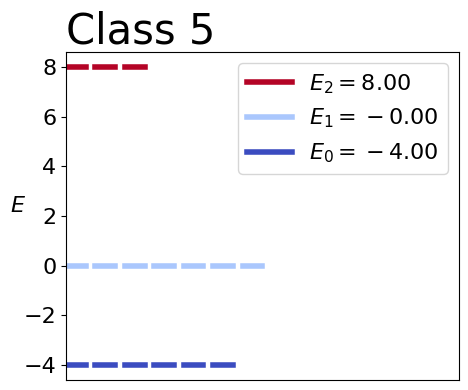

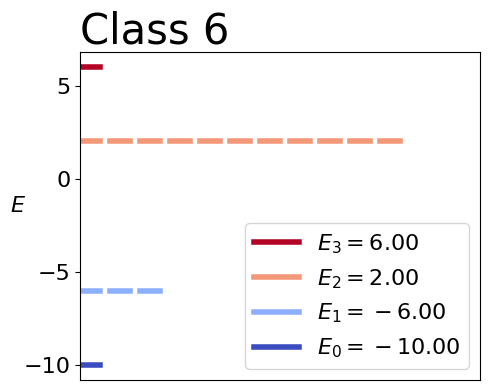

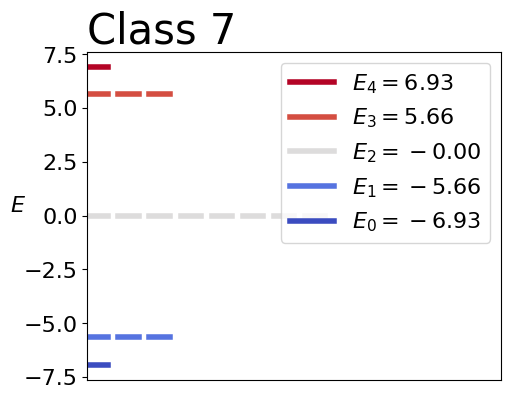

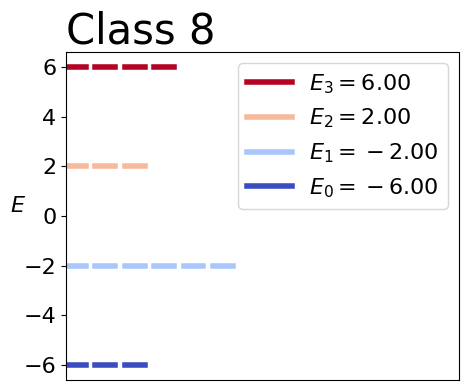

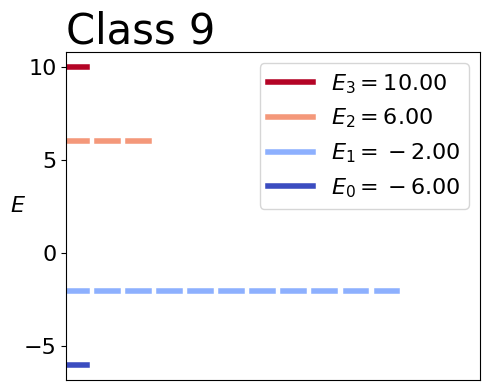

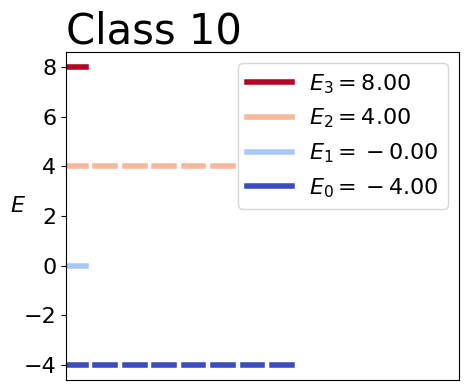

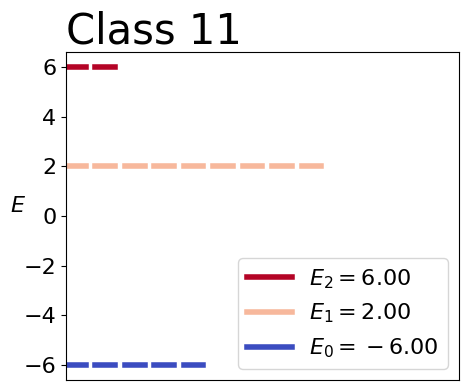

In [5]:
idx = 1
for class_num, set_coefficient in classified_groups.items():
    example_coefficient = set_coefficient[0]
    model = H_sg(example_coefficient)
    title = "Class {}".format(class_num)
    fig, ax = model.plot_energy_level(title=title)
    fig.savefig("../report/figure/class_{}.pdf".format(idx)) 
    idx += 1


### d)

the eigenspectrum of Class 7 exhibits sign-flip invariance. This occurs because the Hamiltonian of Class 7 remains within
Class 7 even after a sign-flip operation is applied to all its eigenvalues.

## Part 2

In [6]:
class AdiabaticSimulator(H_sg):
    def __init__(self, coefficients1, coefficients2, num_qubits=4) -> None:
        super().__init__(coefficients1, coefficients2, num_qubits)
        
        #temp = [self.Pauli_X for _ in range(self.num_qubits)]
        H_m = np.zeros([2**self.num_qubits, 2**self.num_qubits], dtype=np.complex64)
        for i in range(self.num_qubits):
            temp = [self.I for _ in range(self.num_qubits)]
            temp[i] = self.Pauli_X
            H_m -= self._Kron(temp)
        self.H_m = H_m
        
    def Propagator(self, s):
        return (1-s)*self.H_m + s*self.H_sg
    
    def EigenSpectrum(self):
        result = np.zeros([16,1000])
        time_step = np.linspace(0,1,1000)
        for i in range(len(time_step)):
            e_val = np.linalg.eigvalsh(self.Propagator(time_step[i]))
            result[:, i] = e_val
            
        return result
    
    def AdiabaticEvolution(self, tau, N):
        time_step = np.linspace(0, tau, N)
        dt = time_step[1] - time_step[0]
        
        ground_state = np.ones(2**self.num_qubits)/np.sqrt(2**self.num_qubits)
        for t in time_step:
            H = self.Propagator(t/tau)
            propagator = scipy.linalg.expm(-1j*dt*H)
            ground_state = propagator @ ground_state
        
        _, e_vec = np.linalg.eigh(self.H_sg)
        
        exact_ground = e_vec[:, 0]
        
        return ground_state, exact_ground

### a)

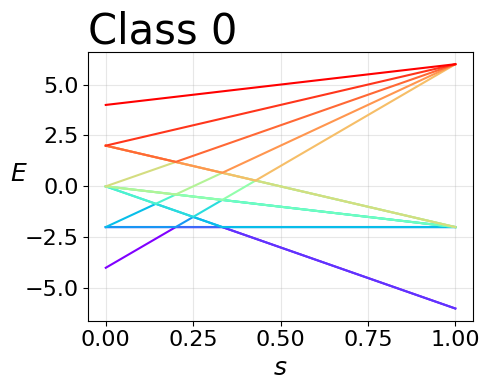

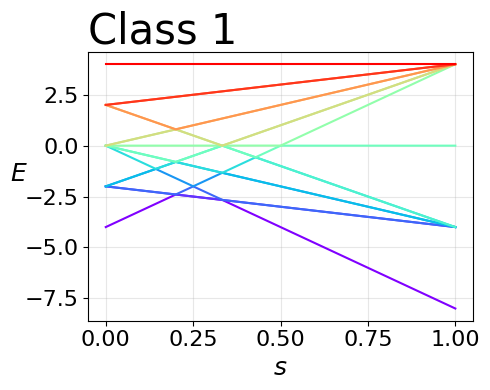

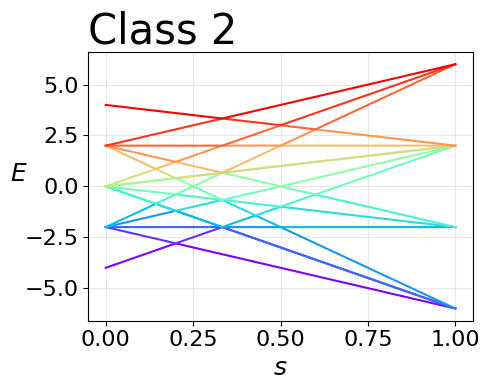

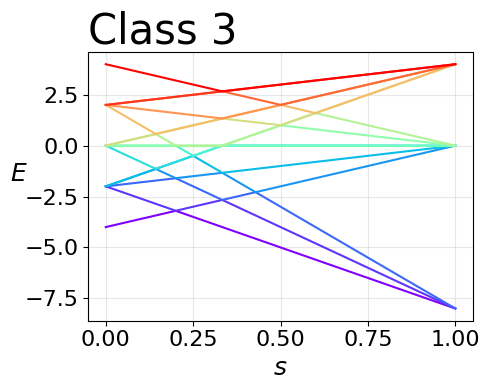

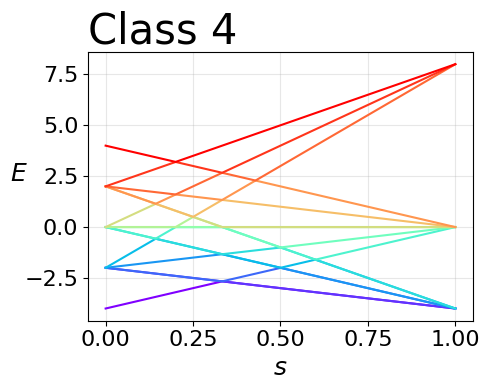

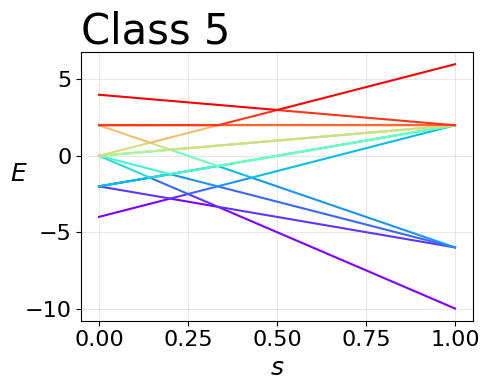

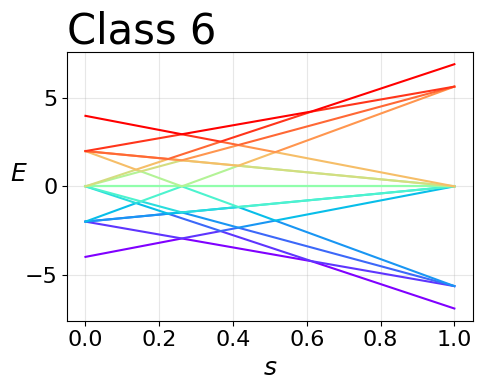

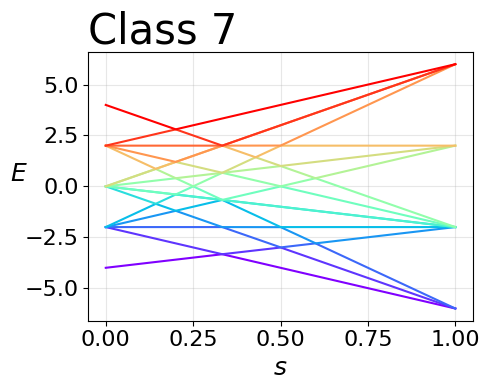

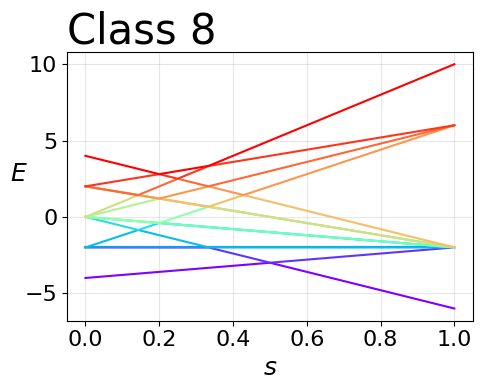

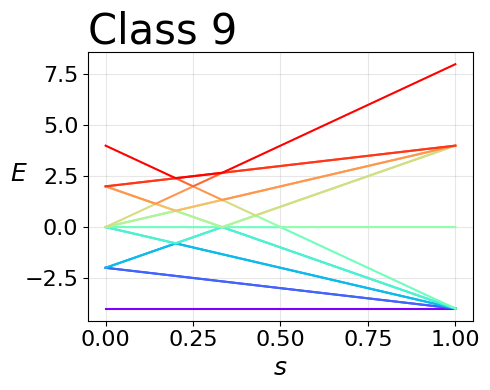

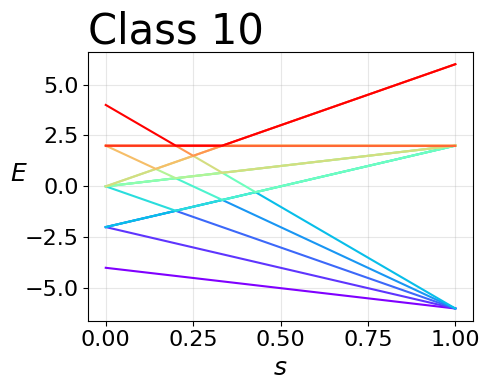

In [7]:
temp = {
    "class_1" : AdiabaticSimulator([1,1,1,1,1,1],[0,0,0,0]),
    "class_2" : AdiabaticSimulator([1,1,1,1,1,-1],[0,0,0,0]),
    "class_3" : AdiabaticSimulator([1,1,1,1,-1,-1],[0,0,0,0]),
    "class_4" : AdiabaticSimulator([1,1,1,-1,-1,-1],[0,0,0,0]),
    "class_5" : AdiabaticSimulator([1,1,-1,1,-1,-1],[0,0,0,0]),
    "class_6" : AdiabaticSimulator([1,1,-1,-1,1,1],[0,0,0,0]),
    "class_7" : AdiabaticSimulator([1,1,-1,-1,1,-1],[0,0,0,0]),
    "class_8" : AdiabaticSimulator([1,1,-1,-1,-1,-1],[0,0,0,0]),
    "class_9" : AdiabaticSimulator([1,-1,-1,-1,-1,1],[0,0,0,0]),
    "class_10": AdiabaticSimulator([1,-1,-1,-1,-1,-1],[0,0,0,0]),
    "class_11": AdiabaticSimulator([-1,-1,-1,-1,-1,-1],[0,0,0,0]),
}

def plot_eigenspectrum(result, title:str=None,figsize=(5,4)):
    fig, ax = plt.subplots(1,1,figsize=figsize)
    time_step = np.linspace(0,1,1000)    
    cmap = mpl.colormaps["rainbow"]
    normalize = mpl.colors.Normalize(vmin=0, vmax=15)

    for i in range(result.shape[0]):
        color = cmap(normalize(i))
        ax.plot(time_step, result[i,:], c=color)
    
    ax.set_ylabel(r"$E$", rotation=0, fontsize=18)
    ax.set_xlabel(r"$s$", rotation=0, fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.grid(alpha=0.3)
    if title is not None:
        ax.set_title(title, loc="left", fontsize=30)
    fig.tight_layout()
    #ax.legend()
    return fig, ax
idx = 0
for key, value in temp.items():
    result = value.EigenSpectrum()
    fig, ax = plot_eigenspectrum(result, "Class {}".format(idx))
    fig.savefig("../report/figure/Eigenspectrum_" + key + ".pdf")
    idx +=1

### b) 

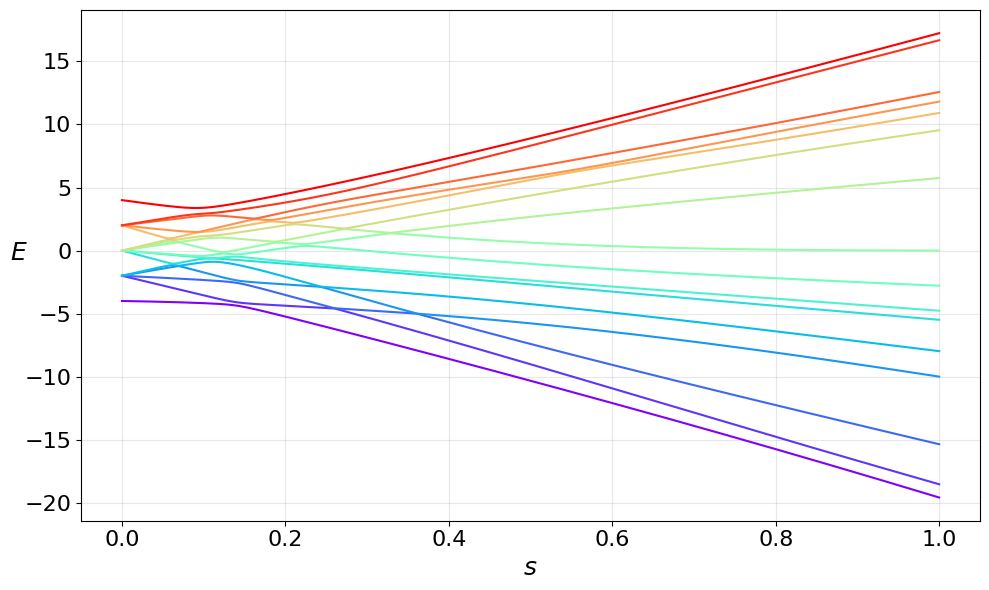

In [8]:
Heisenberg_sg = AdiabaticSimulator([-1,2,3,-2,-3,-4],[1,-1,2,3],4)
result = Heisenberg_sg.EigenSpectrum()
time_step = np.linspace(0,1,1000)
fig, ax = plot_eigenspectrum(result, figsize=(10,6))
fig.savefig("../report/figure/Eigenspectrum_Heisenberg_sg.pdf")

### c)
```python
def AdiabaticEvolution(self, tau, N):
    time_step = np.linspace(0, tau, N)
    dt = time_step[1] - time_step[0]
    
    ground_state = np.ones(2**self.num_qubits)/np.sqrt(2**self.num_qubits)
    for t in time_step:
        H = self.Propagator(t/tau)
        propagator = scipy.linalg.expm(-1j*dt*H)
        ground_state = propagator @ ground_state
    
    _, e_vec = np.linalg.eigh(self.H_sg)
    
    exact_ground = e_vec[:, 0]
    
    return ground_state, exact_ground
```

### d)

In [9]:
gap = np.abs(np.diff(result[[0,1],:], axis=0)).min()

In [10]:
Ep = np.linalg.eigvals(Heisenberg_sg.H_sg - Heisenberg_sg.Propagator(0)).max().real

In [11]:
gap, Ep

(np.float64(0.26657045941897817), np.float32(17.795216))

In [12]:
Ep / gap**2

np.float64(250.42588276057197)

In [13]:
ground_state, exact_ground = Heisenberg_sg.AdiabaticEvolution(250*4,2000)
print("Compare Probability Amplitudes of |0111>, |1011>, |1101>, |1110>")
print("Adiabatic Simulation Results : ", np.abs(ground_state)[[7,11,13,14]])
print("Adiabatic Simulation Results : ", np.abs(exact_ground)[[7,11,13,14]])

Compare Probability Amplitudes of |0111>, |1011>, |1101>, |1110>
Adiabatic Simulation Results :  [0.349 0.307 0.08  0.882]
Adiabatic Simulation Results :  [0.349 0.307 0.08  0.882]


### e), f)

## Part 3

In [14]:
class QAOASimulator(H_sg):
	def __init__(self, coefficients1, coefficients2, index, num_qubits=4) -> None:
		### Note : num_qubits should be fixed as 4
		super().__init__(coefficients1, coefficients2, num_qubits)
		
		self.index = index

		_, exact_ground = np.linalg.eigh(self.H_sg)
		self.exact_ground = exact_ground[:,0]
		self.target = np.abs(self.exact_ground)**2

	def _XY_mixer(self, pair, theta):
		i = pair[0]; j = pair[1]
		temp = [self.I for _ in range(self.num_qubits)]
		X = temp.copy(); Y = temp.copy()
		X[i] = self.Pauli_X; X[j] = self.Pauli_X
		Y[i] = self.Pauli_Y; Y[j] = self.Pauli_Y
		
		mixer = self._Kron(X) + self._Kron(Y)
		mixer = scipy.linalg.expm(-1j*theta/2*mixer)

		return mixer

	def ansatz(self, parameters):
		if len(self.index) != len(parameters):
			raise ValueError("Lengh should be matched")
		
		state = np.zeros(16, dtype=np.complex64)
		state[14] = 1

		operation = [self._XY_mixer(pair, parameter) for pair, parameter in zip(self.index, parameters)]
		for op in operation:
			state = op @ state
	
		return state

	def circuit(self, parameters):
		qc = qiskit.QuantumCircuit(self.num_qubits)
		for i in range(1,self.num_qubits):
			qc.x(i)
		for pair, parameter in zip(self.index, parameters):
			qc.rxx(parameter, pair[0], pair[1])
			qc.ryy(parameter, pair[0], pair[1])
		# TODO : adjust phase
		qc.rz(np.pi/2, 0)
		temp = self.ansatz(parameters)[[7,11,13,14]]
		#print(temp)
		temp[0:3] *= (1j if temp[3] > 0 else -1j)
		temp = (temp > 0)
		for i in range(3):
			qc.rz(np.pi, 3-i) if temp[i] else None

		self.qc = qc
	
		return qc

	def cost(self, parameters):
		state = self.ansatz(parameters)
		amps = np.abs(state)**2
		cost = np.linalg.norm(amps - self.target)

		return cost

	def optimize(self):
		random_para = np.random.rand(3)*2*np.pi
		#initial_para = np.ones(3)
		res = scipy.optimize.minimize(self.cost, random_para, method="L-BFGS-B")
		#sol = res.x
		
		return res

	def _calculate_expectation(self, basis, i, j=None):
		"""
		Calculate the expectation value of <ψ|σ_z^i|ψ> or <ψ|σ_z^i σ_z^j|ψ>.

		Parameters:
			basis (string) : one of "x", "y", and "z"
			i (int): The qubit index for σ_z^i.
			j (int, optional): The qubit index for σ_z^j. If None, only σ_z^i is calculated.

		Returns:
			float: The calculated expectation value.
		"""
		expectation_value = 0

		measurement_outcome = self.measurement_outcome[basis]

		for bitstring, probability in measurement_outcome.items():
			# Extract bits for qubits i (and j if provided)
			bit_i = (int(bitstring, 2) >> i) & 1
			if j is not None:
				bit_j = (int(bitstring, 2) >> j) & 1
				# Determine sign based on parity of bit_i XOR bit_j
				sign = 1 if (bit_i ^ bit_j) == 0 else -1
			else:
				# Sign for single qubit based on whether bit_i is 0 or 1
				sign = 1 if bit_i == 0 else -1

			# Update expectation value with signed probability
			expectation_value += sign * probability

		return expectation_value

	def energy(self):
		energy = 0
		combinations = itertools.combinations([i for i in range(self.num_qubits)], 2)
		
		for coefficient, pair in zip(self.coefficients1, combinations):
			energy += coefficient * self._calculate_expectation("x", pair[0], pair[1])
			energy += coefficient * self._calculate_expectation("y", pair[0], pair[1])
			energy += coefficient * self._calculate_expectation("z", pair[0], pair[1])
		
		for idx, coefficient in enumerate(self.coefficients2):
			energy += coefficient * self._calculate_expectation("z", idx)
   
		return energy
		
	def perform_measure(self, num_shots=10000):
	
		qc_x = self.qc.copy()
		qc_y = self.qc.copy()
		qc_z = self.qc.copy()

		for i in range(self.num_qubits):
			qc_x.h(i)
			qc_y.s(i)
			qc_y.h(i)

		qc_x.measure_all()
		qc_y.measure_all()
		qc_z.measure_all()
	
		outcome_x = MeasurementResultHandler(backend.run(qc_x, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)
		outcome_y = MeasurementResultHandler(backend.run(qc_y, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)
		outcome_z = MeasurementResultHandler(backend.run(qc_z, shots=num_shots).result().data()["counts"], self.num_qubits, num_shots)

		self.measurement_outcome = {
			"x" : outcome_x,
			"y" : outcome_y,
			"z" : outcome_z,
		}
	
		return self.measurement_outcome

### a), b), c)

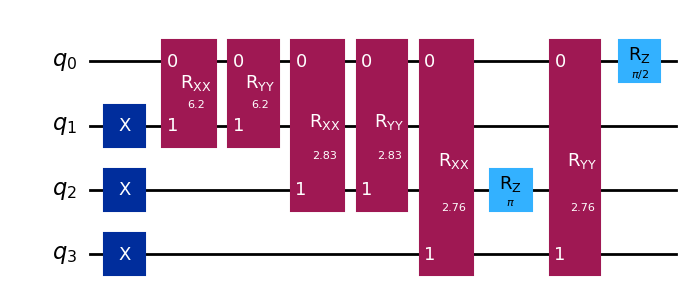

In [15]:
QAOASimulator = QAOASimulator([-1,2,3,-2,-3,-4],[1,-1,2,3],[(0,1),(0,2),(0,3)],4)
sol = QAOASimulator.optimize()
sol, sol.x % (2*np.pi)
QAOASimulator.circuit(sol.x).draw("mpl")

### d)

In [16]:
num_shots = 1e7
outcome = QAOASimulator.perform_measure(num_shots=num_shots)
ground_energy =  QAOASimulator.energy()
print("Estimated Ground Energy : ", ground_energy)

e, v = np.linalg.eigh(QAOASimulator.H_sg)
print("Exact Ground Energy : ", e.min())

Estimated Ground Energy :  -19.5893588
Exact Ground Energy :  -19.587343
